In [161]:
import network
import pandas as pd
import geopandas as gpd
import numpy as np
from datetime import datetime
import importlib
importlib.reload(network)
import matplotlib.pyplot as plt
import types
from IPython.display import clear_output
import os
import seaborn as sns
import osmnx as ox
from joblib import dump,load
import contextily as cx
from pathlib import Path
import re

In [3]:
plt.rcdefaults()
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 14,
    'legend.title_fontsize': 16,
})

In [171]:
r1_file = 'Figures/reseaux/MTL_fixed_benefit-01-21/'
r2_file = 'Figures/reseaux/MTL_100k_fpkm-01-30/'
r3_file = 'Figures/reseaux/MTL_fill-02-03/'

R1 = ox.io.load_graphml(r1_file+'network_it_final.graphml')
R2 = ox.io.load_graphml(r2_file+'network_it_final.graphml')
R3 = ox.io.load_graphml(r3_file+'network_it_final.graphml')


In [172]:
r1_nodes,r1_edges = ox.graph_to_gdfs(R1)
r2_nodes,r2_edges = ox.graph_to_gdfs(R2)
r3_nodes,r3_edges = ox.graph_to_gdfs(R3)


In [174]:
r1_edges['build_iter'] = r1_edges['build_iter'].astype(int)
r2_edges['build_iter'] = r2_edges['build_iter'].astype(int)
r3_edges['build_iter'] = r3_edges['build_iter'].astype(int)


In [175]:
new_r1_edges = r1_edges[r1_edges.build_iter>0]
new_r2_edges = r2_edges[r2_edges.build_iter>0]
new_r3_edges = r3_edges[r3_edges.build_iter>0]


In [181]:
common_edges_r1r2 = pd.merge(new_r2_edges,new_r1_edges,right_index=True,left_index=True)
common_edges_r1r3 = pd.merge(new_r3_edges,new_r1_edges,right_index=True,left_index=True)
common_edges_r2r3 = pd.merge(new_r2_edges,new_r3_edges,right_index=True,left_index=True)
common_edges_all = pd.merge(common_edges_r1r2,common_edges_r2r3,left_index=True,right_index=True)

r2_only = new_r2_edges.drop(common_edges_r1r2.index.append(common_edges_r2r3.index))
r1_only = new_r1_edges.drop(common_edges_r1r2.index.append(common_edges_r1r3.index))
r3_only = new_r3_edges.drop(common_edges_r1r3.index.append(common_edges_r2r3.index))



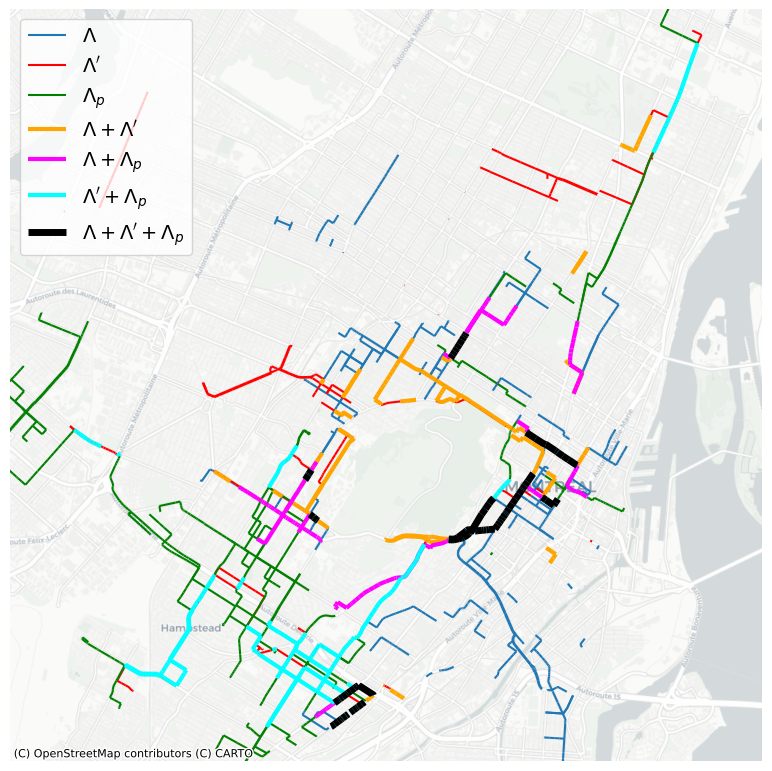

In [197]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf_r1 = r1_only.to_crs(epsg=3857)
gdf_r2 = r2_only.to_crs(epsg=3857)
gdf_r3 = r3_only.to_crs(epsg=3857)

gdf_r1r2 = common_edges_r1r2.set_geometry('geometry_x').to_crs(epsg = 3857)
gdf_r1r3 = common_edges_r1r3.set_geometry('geometry_x').to_crs(epsg = 3857)
gdf_r2r3 = common_edges_r2r3.set_geometry('geometry_x').to_crs(epsg = 3857)

gdf_common = common_edges_all.set_geometry('geometry_x_x').to_crs(epsg=3857)

xmin, ymin, xmax, ymax = pd.concat([gdf_r1r3,gdf_r2r3]).total_bounds
        
x_span = xmax-xmin
y_span = ymax-ymin

max_edge = max(x_span,y_span)*1.1



gdf_r1.plot(ax=ax,label = '$\Lambda$')
gdf_r2.plot(ax=ax,label = '$\Lambda\'$',color = 'red')
gdf_r3.plot(ax=ax,label = '$\Lambda_{p}$',color = 'green')

gdf_r1r2.plot(ax=ax,label = '$\Lambda+\Lambda\'$',color = 'orange',linewidth = 3)
gdf_r1r3.plot(ax=ax,label = '$\Lambda+\Lambda_p$',color = 'magenta',linewidth = 3)
gdf_r2r3.plot(ax=ax,label = '$\Lambda\'+\Lambda_p$',color = 'cyan',linewidth = 3)

gdf_common.plot(ax=ax,label = '$\Lambda+\Lambda\'+\Lambda_p$',color = 'black',linewidth = 5)


ax.set_xlim((xmin+xmax-max_edge)/2, (xmin+xmax+max_edge)/2)
ax.set_ylim((ymin+ymax-max_edge)/2, (ymin+ymax+max_edge)/2)
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron
)

ax.set_axis_off()
plt.tight_layout()
ax.legend(loc = 'upper left')
plt.show()
fig.savefig(f'Figures/Memoire/comp_3_metriques_closeup.png',bbox_inches = 'tight')

In [200]:
r1_sum = max(
    (
        (int(m.group(1)), f)
        for f in Path(r1_file).iterdir()
        if (m := re.match(r"^summary_(\d+)\.csv$", f.name))
    ),
    key=lambda x: x[0]
)[1]
r2_sum = max(
    (
        (int(m.group(1)), f)
        for f in Path(r2_file).iterdir()
        if (m := re.match(r"^summary_(\d+)\.csv$", f.name))
    ),
    key=lambda x: x[0]
)[1]
r3_sum = max(
    (
        (int(m.group(1)), f)
        for f in Path(r3_file).iterdir()
        if (m := re.match(r"^summary_(\d+)\.csv$", f.name))
    ),
    key=lambda x: x[0]
)[1]
r1_sum = pd.read_csv(r1_sum,index_col = 'ipere')
r2_sum = pd.read_csv(r2_sum,index_col = 'ipere')
r3_sum = pd.read_csv(r3_sum,index_col = 'ipere')

orig_sum = pd.read_csv('Figures/reseaux/MTL_fixed_benefit-01-21/summary_0.csv',index_col = 'ipere')


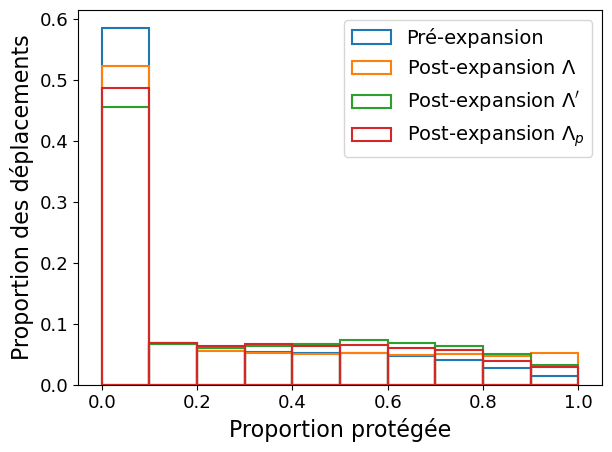

In [209]:
fig, ax = plt.subplots()

sns.histplot(orig_sum,x = 'prop_cycleway',binwidth = 0.1,label = 'Pré-expansion',ax = ax,fill = False,stat = 'proportion')
sns.histplot(r1_sum,x = 'prop_cycleway',binwidth = 0.1,label = 'Post-expansion $\Lambda$',ax = ax,fill = False,stat = 'proportion')
sns.histplot(r2_sum,x = 'prop_cycleway',binwidth = 0.1,label = 'Post-expansion $\Lambda\'$',ax = ax,fill = False,stat = 'proportion')
sns.histplot(r3_sum,x = 'prop_cycleway',binwidth = 0.1,label = 'Post-expansion $\Lambda_p$',ax = ax,fill = False,stat = 'proportion')

ax.set_xlabel('Proportion protégée')
ax.set_ylabel('Proportion des déplacements')
ax.legend()
fig.tight_layout()
fig.savefig('Figures/Memoire/PP_comp_3_metriques.png',bbox_inches = 'tight')

In [210]:
routes_summary_orig = pd.read_csv('Data/Clustering/clusters_dep_MTL.csv',index_col='route_number')
scaler = load('Data/Clustering/scaler_trajets.joblib')
kmeans = load('Data/Clustering/kmeans_trajets.joblib')

In [211]:
routes_summary = r1_sum.merge(routes_summary_orig, left_index = True,right_index = True)
routes_summary['ABD'] = routes_summary['total_length']-routes_summary['shortest_network_dist']
routes_summary['BDR'] = routes_summary['total_length']/routes_summary['shortest_network_dist']

routes_summary_2 = r2_sum.merge(routes_summary_orig, left_index = True,right_index = True)
routes_summary_2['ABD'] = routes_summary_2['total_length']-routes_summary_2['shortest_network_dist']
routes_summary_2['BDR'] = routes_summary_2['total_length']/routes_summary_2['shortest_network_dist']

routes_summary_3 = r3_sum.merge(routes_summary_orig, left_index = True,right_index = True)
routes_summary_3['ABD'] = routes_summary_3['total_length']-routes_summary_3['shortest_network_dist']
routes_summary_3['BDR'] = routes_summary_3['total_length']/routes_summary_3['shortest_network_dist']

In [212]:
variables = ['tort_x','total_length','ABD','BDR','prop_cycleway_x']
new_clusters = kmeans.predict(scaler.transform(routes_summary[variables].to_numpy()))
new_clusters_2 = kmeans.predict(scaler.transform(routes_summary_2[variables].to_numpy()))
new_clusters_3 = kmeans.predict(scaler.transform(routes_summary_3[variables].to_numpy()))


routes_summary['new_cluster'] = new_clusters
cluster_to_name = (
    routes_summary.drop_duplicates("cluster")
      .set_index("cluster")["cluster_name"]
)
routes_summary["new_cluster_name"] = routes_summary["new_cluster"].map(cluster_to_name)

routes_summary_2['new_cluster'] = new_clusters_2
cluster_to_name = (
    routes_summary_2.drop_duplicates("cluster")
      .set_index("cluster")["cluster_name"]
)
routes_summary_2["new_cluster_name"] = routes_summary_2["new_cluster"].map(cluster_to_name)

routes_summary_3['new_cluster'] = new_clusters_3
cluster_to_name = (
    routes_summary_3.drop_duplicates("cluster")
      .set_index("cluster")["cluster_name"]
)
routes_summary_3["new_cluster_name"] = routes_summary_3["new_cluster"].map(cluster_to_name)

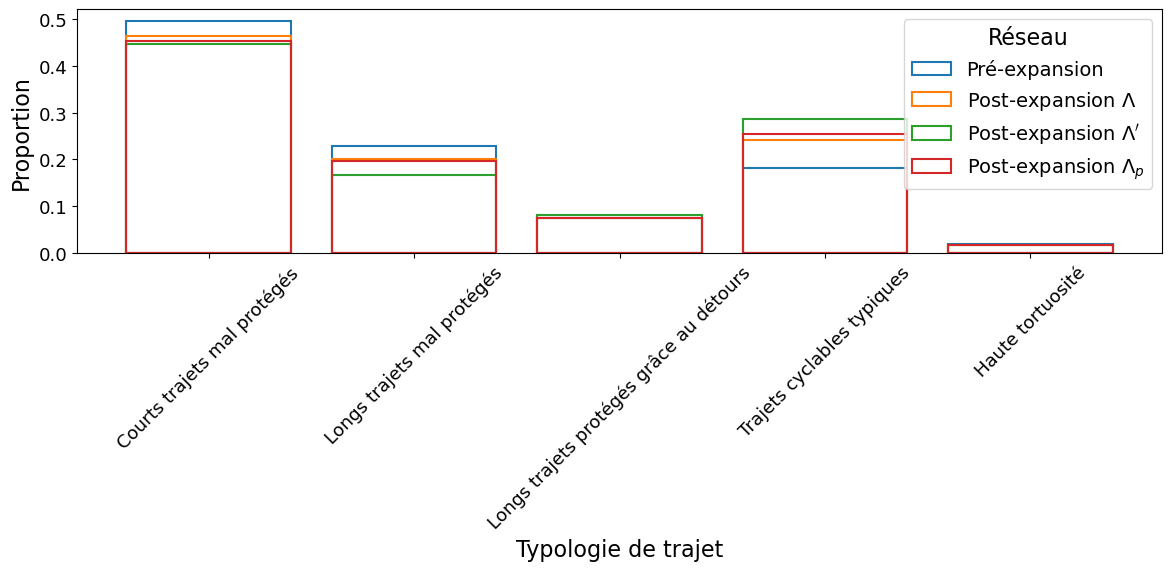

In [214]:
fig, ax = plt.subplots(figsize = (12,6))

sns.histplot(routes_summary,x = 'cluster_name',stat = 'proportion',discrete = True,common_norm = False,shrink = 0.8,ax = ax,fill = False,label = 'Pré-expansion')
sns.histplot(routes_summary,x = 'new_cluster_name',stat = 'proportion',discrete = True,common_norm = False,shrink = 0.8,ax = ax,fill = False,label = 'Post-expansion $\Lambda$')
sns.histplot(routes_summary_2,x = 'new_cluster_name',stat = 'proportion',discrete = True,common_norm = False,shrink = 0.8,ax = ax,fill = False,label = 'Post-expansion $\Lambda\'$')
sns.histplot(routes_summary_3,x = 'new_cluster_name',stat = 'proportion',discrete = True,common_norm = False,shrink = 0.8,ax = ax,fill = False,label = 'Post-expansion $\Lambda_p$')

plt.xticks(rotation=45)

handles, labels = ax.get_legend_handles_labels()


plt.legend(handles, labels, title = 'Réseau')
ax.set_xlabel('Typologie de trajet')
fig.tight_layout()
fig.savefig(f'Figures/Memoire/lambdas_hist_typologie_trajets.png',bbox_inches = 'tight')

In [216]:
gdf_common.explore(tiles = 'CartoDB Positron')